In [1]:
# 1. LIBRARY IMPORTS

import torch                  # Core PyTorch library for tensor operations and deep learning
import pandas as pd            # Data manipulation and analysis tool for structured data (DataFrames)
import numpy as np             # Numerical computing library for array processing and math operations
import matplotlib.pyplot as plt # Plotting library for creating static, animated, and interactive visualizations
from torch import nn           # PyTorch neural network module containing layers, loss functions, and activation functions

In [2]:
# 2. DATA LOADING
# Load the tabular housing dataset into a Pandas DataFrame
df = pd.read_csv("house_price_regression_dataset.csv")

In [3]:
# 3. SPLITTING TARGET VARIABLE AND FEATURES

# Extract the target variable (the dependent variable we want to predict)
y = df["House_Price"]

# Drop the target column from the dataset to isolate the independent input features
x = df.drop("House_Price" , axis=1)

In [4]:
# 4. DROPPING UNNECESSARY FEATURES
# Drop 'Year_Built' because it contains noise and weak correlation with house prices,
# modifying the DataFrame in place to save memory.
x.drop("Year_Built", axis=1, inplace=True)

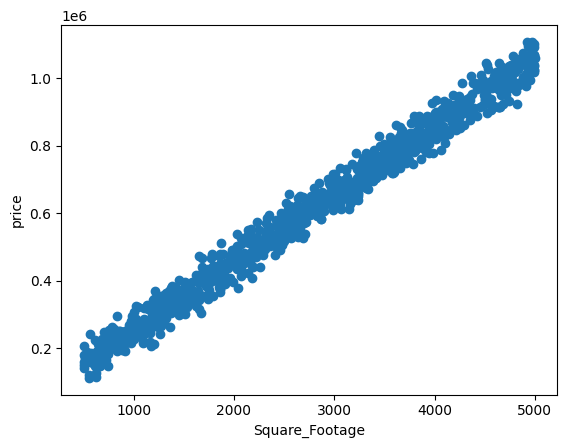

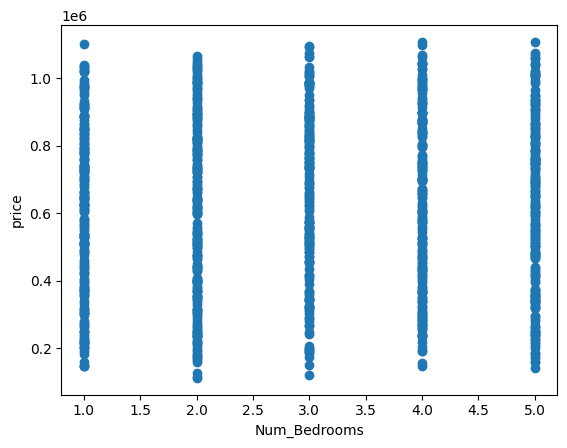

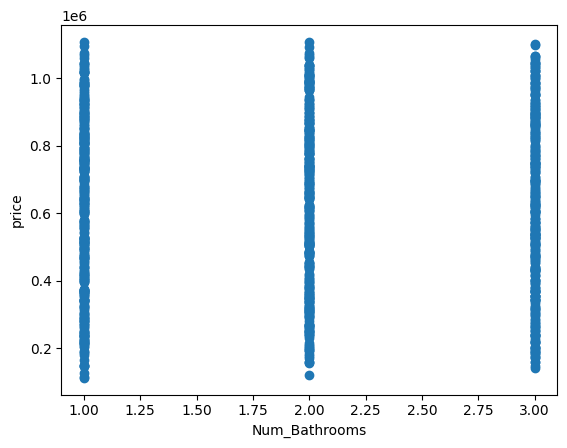

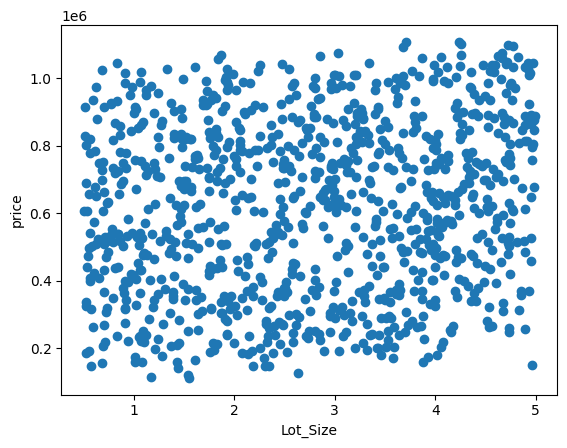

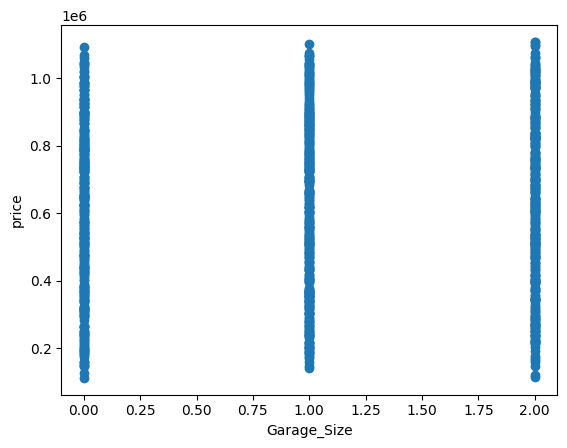

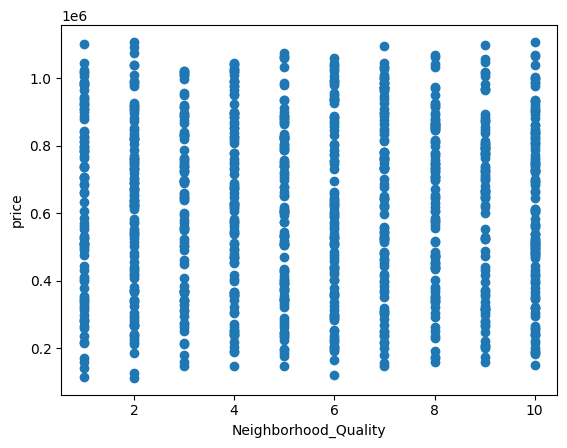

In [5]:
# 5. DATA VISUALIZATION (EXPLORATORY DATA ANALYSIS)
# Loop through each remaining feature to generate scatter plots against house prices
for _ in x.columns:
    plt.scatter(x[_], y)       # Plot the feature values on the X-axis vs the real prices on the Y-axis
    plt.xlabel(_)              # Label the X-axis with the current feature name
    plt.ylabel("price")        # Label the Y-axis as price
    plt.show()                 # Render and display the individual plot

In [6]:
# 6. HARDWARE ACCELERATION SETUP
# Select GPU (CUDA) if available for faster training, otherwise fallback to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
# 7. CATEGORICAL ENCODING (ONE-HOT ENCODING)
# Convert categorical columns and discrete values into numeric binary dummy variables (0 or 1)
# to prevent the linear model from misinterpreting arbitrary ordered numbers, 
# then cast the entire DataFrame to float for tensor compatibility.
x = pd.get_dummies(df, columns=["Num_Bathrooms", "Num_Bedrooms", "Garage_Size", "Neighborhood_Quality"]).astype(float)

In [8]:
x = x.drop(["House_Price" ,"Year_Built"] , axis=1)

In [9]:
# 9. FEATURE AND TARGET SCALING (STANDARDIZATION)
from sklearn.preprocessing import StandardScaler

# Initialize the feature scaler and normalize 'Square_Footage' to have a mean of 0 and variance of 1
scaler = StandardScaler() 
x["Square_Footage"] = scaler.fit_transform(x[["Square_Footage"]])

# Initialize a separate scaler for the target variable (y) to scale the house prices,
# reshaping it to a 2D array (-1, 1) to match the expected input shape of the scaler
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.to_numpy().reshape(-1, 1))

In [10]:
# 10. PYTORCH TENSOR CONVERSION & DEVICE ALLOCATION
# Convert features DataFrame to NumPy array, cast to PyTorch float32 tensor, and push to selected device
x = torch.tensor(x.to_numpy(), dtype=torch.float32, device=device)

# Cast scaled target array to PyTorch float32 tensor and push to the same device (GPU or CPU)
y_scaled = torch.tensor(y_scaled, dtype=torch.float32, device=device)

In [11]:
y_scaled.shape , x.shape

(torch.Size([1000, 1]), torch.Size([1000, 23]))

In [12]:
# 11. TRAIN-TEST SPLIT (80% TRAINING, 20% TESTING)
# Calculate the split index corresponding to 80% of the dataset
split = int(len(y_scaled) * 0.8)

# Slice the features and targets to create training sets (80%) and testing sets (20%)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

In [13]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

(torch.Size([800, 23]),
 torch.Size([200, 23]),
 torch.Size([800, 1]),
 torch.Size([200, 1]))

In [14]:
# 12. DEEP NEURAL NETWORK ARCHITECTURE FOR REGRESSION
class linear_reg(nn.Module):
    def __init__(self):
        super().__init__()
        # Input Layer: Takes 23 encoded features and expands to 100 hidden units
        self.linear1 = nn.Linear(23, 100)
        self.bn1 = nn.BatchNorm1d(100)        # Stabilizes learning and accelerates training
        self.act1 = nn.ReLU()                  # Introduces non-linearity
        
        # Hidden Layer: Compresses 100 units down to 50 hidden units
        self.linear2 = nn.Linear(100, 50)
        self.bn2 = nn.BatchNorm1d(50)         # Normalizes the activations of the second layer
        self.act2 = nn.ReLU()                  # Introduces non-linearity
        self.dropout = nn.Dropout(p=0.2)       # Randomly deactivates 20% of neurons to prevent overfitting
      
        # Output Layer: Maps 50 features down to 1 continuous target prediction (House Price)
        self.linear_out = nn.Linear(50, 1)

    def forward(self, x):
        # Pass data through the first block (Linear -> BatchNorm -> ReLU)
        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act1(x)
        
        # Pass data through the second block with Dropout regularization
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.bn2(x) 
        x = self.act2(x)
        x = self.dropout(x)
        
        # Final output projection
        return self.linear_out(x)

In [15]:
# 13. MODEL INSTANTIATION
# Instantiate the neural network and transfer its parameters/weights to the selected device (GPU/CPU)
model = linear_reg().to(device)

In [16]:
# 14. OPTIMIZER AND LOSS FUNCTION CONFIGURATION
# Initialize the Adam optimizer to update model weights using a learning rate of 0.01
optimizar = torch.optim.Adam(params=model.parameters(), lr=0.01)

# Define Mean Absolute Error (MAE) as the L1 Loss function for training
loss_fun  = nn.L1Loss()

In [17]:

# 15. MODEL TRAINING AND VALIDATION LOOP
from tqdm import tqdm

# Set random seed for CUDA reproducibility
seed = torch.cuda.manual_seed(111)
epochs = 500 
loss_train = []
loss_test = []
epoch = 0

# Start training loop with a progress bar
for epochs in tqdm(range(epochs)):
    model.train()
    model.to(device=device)        # Ensure model parameters are on the correct device
    y_pred = model(x_train)        # Forward pass: compute predictions on training features
    
    loss = loss_fun(y_pred, y_train) # Calculate the training loss (MAE)
    optimizar.zero_grad()          # Reset gradients from the previous iteration
    
   
    loss.backward()                # Backward pass: compute gradient of the loss w.r.t model parameters
    optimizar.step()               # Update model weights based on computed gradients
    
    loss_train.append(loss.item()) # Log historical training loss value

    # Switch model to evaluation mode (deactivates dropout and batch normalization behaviors)
    model.eval()

    # Temporarily disable gradient calculation to optimize memory and speed during inference
    with torch.inference_mode():
        test_pred = model(x_test)      # Forward pass: compute predictions on testing features
        
        test_loss = loss_fun(test_pred, y_test) # Calculate validation/testing loss
        loss_test.append(test_loss.item())

100%|██████████| 500/500 [00:02<00:00, 172.68it/s]


In [18]:
# 16. LOSS PERFORMANCE CHECK
# Extract the absolute lowest training loss achieved and compare it with the final evaluation test loss
min(loss_train), test_loss

(0.09466409683227539, tensor(0.0866, device='cuda:0'))

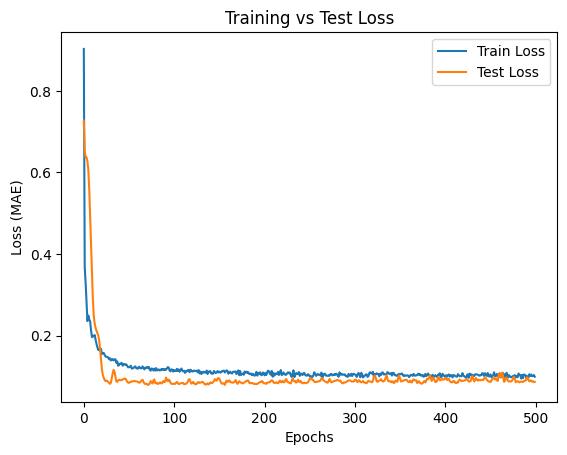

In [19]:
# 17. LOSS CURVE PLOTTING (TRAIN vs TEST LOSS)

plt.plot(loss_train, label="Train Loss")  
# Plot training loss values across all epochs to show how the model learns over time

plt.plot(loss_test, label="Test Loss")  
# Plot testing/validation loss to compare generalization performance with training

plt.title("Training vs Test Loss")  
# Add a title to clearly describe the comparison between training and test performance

plt.xlabel("Epochs")  
# Label x-axis as training iterations (epochs)

plt.ylabel("Loss (MAE)")  
# Label y-axis as Mean Absolute Error to show error magnitude

plt.legend()  
# Show legend to distinguish between Train Loss and Test Loss curves

plt.show()  
# Render and display the final loss comparison graph

In [20]:
# 18. MODEL EVALUATION & INVERSE PERFORMANCE METRICS
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Convert tensors back to CPU, transform to NumPy, and reverse the scaling 
# to get the actual dollar values for both predictions and actual prices.
real_predictions = scaler_y.inverse_transform(test_pred.cpu().numpy())
real_prices = scaler_y.inverse_transform(y_test.cpu().numpy())

# Calculate and display regression performance metrics on original-scale data
print(f"R² Score (Accuracy)     : {r2_score(real_prices, real_predictions) * 100:.2f}%")
print(f"Mean Absolute Error     : ${mean_absolute_error(real_prices, real_predictions):,.2f}")
print(f"Mean Squared Error      : {mean_squared_error(real_prices, real_predictions):,.2f}")
print(f"Root Mean Squared Error : ${root_mean_squared_error(real_prices, real_predictions):,.2f}")

R² Score (Accuracy)     : 98.82%
Mean Absolute Error     : $21,956.57
Mean Squared Error      : 719,138,496.00
Root Mean Squared Error : $26,816.76


In [21]:
model.state_dict()

OrderedDict([('linear1.weight',
              tensor([[-0.3080, -0.1007, -0.2533,  ...,  0.2852,  0.0711, -0.3892],
                      [-0.1167, -0.2273,  0.0176,  ...,  0.3041, -0.0968, -0.4241],
                      [-0.4127, -0.0477,  0.1134,  ..., -0.0145,  0.0350, -0.0094],
                      ...,
                      [ 0.4478,  0.1639, -0.1033,  ...,  0.0344, -0.0769, -0.0554],
                      [ 0.4915,  0.0402, -0.1487,  ...,  0.2156,  0.3829, -0.1198],
                      [ 0.4772, -0.0061,  0.0660,  ..., -0.0284,  0.0153, -0.0195]],
                     device='cuda:0')),
             ('linear1.bias',
              tensor([-1.1181e-01, -1.7648e-01, -1.5190e-01, -1.1251e-01, -2.1669e-01,
                       1.2208e-01, -1.7296e-01,  8.5565e-02, -1.3827e-01,  2.1209e-01,
                       6.7581e-02,  1.4809e-01,  9.3040e-02, -1.4712e-01,  1.9361e-01,
                      -4.5964e-02, -1.0129e-01, -1.2787e-01, -2.9306e-02, -1.7296e-01,
                  

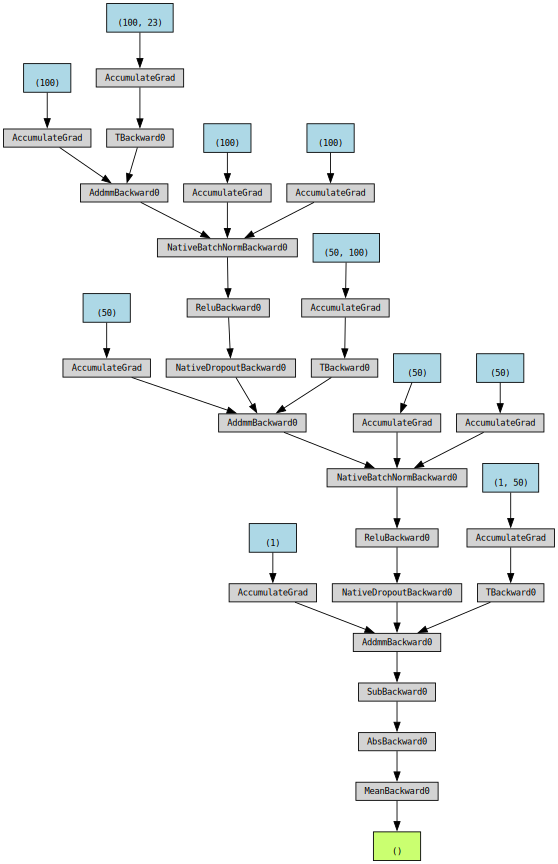

In [22]:
from torchviz import make_dot

make_dot(loss,  params=model.state_dict())

In [23]:
torch.save(model.state_dict() , "model.pt")

In [24]:
x = x.cpu().numpy()
np.save("dataset.npy" ,x )

In [25]:
import joblib
joblib.dump(scaler_y , "scaler_y.pt")

['scaler_y.pt']